# Задание 4: Логистика и поставки
**Цель:** Определить факторы задержек, проанализировать стоимость доставки, оптимизировать маршруты и построить KPI по водителям.

## 1. Импорты и загрузка данных

In [1]:
import io
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from minio import Minio
import pyarrow.parquet as pq
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report
import warnings
warnings.filterwarnings('ignore')

client = Minio('minio:9000', access_key='minioadmin',
               secret_key='minioadmin123', secure=False)
BUCKET = 'oil-pipeline'

def read_parquet(prefix):
    objs = list(client.list_objects(BUCKET, prefix=prefix, recursive=True))
    dfs  = [pq.read_table(io.BytesIO(
                client.get_object(BUCKET, o.object_name).read())).to_pandas()
            for o in objs if o.object_name.endswith('.parquet')]
    return pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()

df_del  = read_parquet('raw/deliveries/')
df_drv  = read_parquet('raw/drivers/')
df_veh  = read_parquet('raw/vehicles/')

df_del['date'] = pd.to_datetime(df_del['date'])

# Объединяем
df = df_del.merge(df_drv[['driver_id', 'name', 'experience_years', 'region']],
                  on='driver_id', how='left')
df = df.merge(df_veh[['vehicle_id', 'plate_number', 'capacity_ton', 'fuel_type']],
              on='vehicle_id', how='left')
df = df.rename(columns={'name': 'driver_name'})

print(f'Поставок: {len(df)}')
df.head(3)

Поставок: 30


,delivery_id,date,source,destination,product_type,volume_ton,cost_usd,delay_hours,distance_km,weather_conditions,driver_id,vehicle_id,driver_name,experience_years,region,plate_number,capacity_ton,fuel_type
0,1,2025-10-01,Base-Khanty,Station-01,Diesel,32.5,2100.50,0.0,180.0,Clear,1,1,Ivan Petrov,8,Khanty-Mansi,X123HM89,40.0,diesel
1,2,2025-10-01,Base-Tomsk,Station-02,Gasoline,28.0,1850.00,1.5,150.0,Rain,2,2,Sergey Sidorov,12,Tomsk,K456TM70,35.0,diesel
2,3,2025-10-01,Base-Tyumen,Station-03,Diesel,22.0,1650.25,0.0,120.0,Clear,3,3,Aleksey Smirnov,5,Tyumen,A789PO72,25.0,gas


## 2. Очистка и Feature Engineering

In [2]:
print('Пропуски:', df.isnull().sum().to_dict())
df = df.dropna(subset=['delay_hours', 'cost_usd', 'distance_km'])

# Дополнительные признаки
df['cost_per_km']    = (df['cost_usd'] / df['distance_km']).round(2)
df['load_factor']    = (df['volume_ton'] / df['capacity_ton']).round(2)
df['is_delayed']     = (df['delay_hours'] > 0).astype(int)
df['delay_category'] = pd.cut(df['delay_hours'],
                               bins=[-0.01, 0, 1, 3, 100],
                               labels=['Без задержки', 'Лёгкая (≤1ч)', 'Умеренная (1-3ч)', 'Серьёзная (>3ч)'])

print(f'\nЗадержанных поставок: {df["is_delayed"].sum()} из {len(df)} ({df["is_delayed"].mean()*100:.0f}%)')
print('\nРаспределение задержек:')
display(df['delay_category'].value_counts())

Пропуски: {'delivery_id': 0, 'date': 0, 'source': 0, 'destination': 0, 'product_type': 0, 'volume_ton': 0, 'cost_usd': 0, 'delay_hours': 0, 'distance_km': 0, 'weather_conditions': 0, 'driver_id': 0, 'vehicle_id': 0, 'driver_name': 0, 'experience_years': 0, 'region': 0, 'plate_number': 0, 'capacity_ton': 0, 'fuel_type': 0}

Задержанных поставок: 16 из 30 (53%)

Распределение задержек:


delay_category
Без задержки        14
Лёгкая (≤1ч)         7
Умеренная (1-3ч)     7
Серьёзная (>3ч)      2
Name: count, dtype: int64

## 3. Факторы задержек
### 3.1 Влияние погоды

In [3]:
weather_stats = df.groupby('weather_conditions').agg(
    avg_delay   = ('delay_hours',  'mean'),
    total_trips = ('delivery_id',  'count'),
    delayed_pct = ('is_delayed',   'mean'),
).reset_index()
weather_stats['delayed_pct'] = (weather_stats['delayed_pct'] * 100).round(1)
weather_stats = weather_stats.sort_values('avg_delay', ascending=False)

print('Влияние погоды на задержки:')
display(weather_stats)

Влияние погоды на задержки:


,weather_conditions,avg_delay,total_trips,delayed_pct
4,Snow,3.500,3,100.0
3,Rain,2.000,5,100.0
2,Fog,1.500,3,100.0
1,Cloudy,0.375,4,75.0
0,Clear,0.100,15,13.3


### 3.2 Влияние расстояния и водителя

In [4]:
driver_kpi = df.groupby(['driver_id', 'driver_name', 'experience_years']).agg(
    trips         = ('delivery_id',  'count'),
    avg_delay     = ('delay_hours',  'mean'),
    delayed_pct   = ('is_delayed',   'mean'),
    avg_cost_km   = ('cost_per_km',  'mean'),
    total_volume  = ('volume_ton',   'sum'),
).reset_index()
driver_kpi['delayed_pct'] = (driver_kpi['delayed_pct'] * 100).round(1)
driver_kpi = driver_kpi.sort_values('avg_delay')

print('KPI по водителям:')
display(driver_kpi[['driver_name', 'trips', 'avg_delay', 'delayed_pct',
                     'avg_cost_km', 'total_volume', 'experience_years']])

KPI по водителям:


,driver_name,trips,avg_delay,delayed_pct,avg_cost_km,total_volume,experience_years
0,Ivan Petrov,5,0.200000,20.0,11.728000,168.4,8
2,Aleksey Smirnov,7,0.428571,14.3,13.261429,165.1,5
3,Pavel Egorov,4,0.625000,50.0,11.755000,130.7,15
1,Sergey Sidorov,7,0.785714,71.4,12.298571,195.2,12
4,Andrey Kuznetsov,7,2.285714,100.0,13.587143,141.1,10


## 4. Анализ стоимости: Cost / km

In [5]:
print('Статистика стоимости доставки:')
display(df[['cost_usd', 'cost_per_km', 'distance_km', 'volume_ton']].describe().round(2))

# По типу продукта
product_cost = df.groupby('product_type').agg(
    avg_cost_km  = ('cost_per_km', 'mean'),
    total_volume = ('volume_ton',  'sum'),
    trips        = ('delivery_id', 'count'),
).reset_index().sort_values('avg_cost_km')
print('\nСредняя стоимость по типу продукта:')
display(product_cost)

Статистика стоимости доставки:


,cost_usd,cost_per_km,distance_km,volume_ton
count,30.00,30.00,30.00,30.00
mean,1826.92,12.66,146.40,26.68
std,285.72,0.94,32.02,5.38
min,1400.40,11.25,100.00,18.00
25%,1652.69,11.86,120.50,22.15
50%,1800.10,12.20,149.50,26.90
75%,2075.22,13.54,173.75,31.60
max,2400.80,14.00,210.00,35.00



Средняя стоимость по типу продукта:


,product_type,avg_cost_km,total_volume,trips
1,Gasoline,12.131250,214.0,8
0,Diesel,12.762667,424.9,15
2,Kerosene,13.028571,161.6,7


## 5. Визуализации
### 5.1 Delay vs Weather

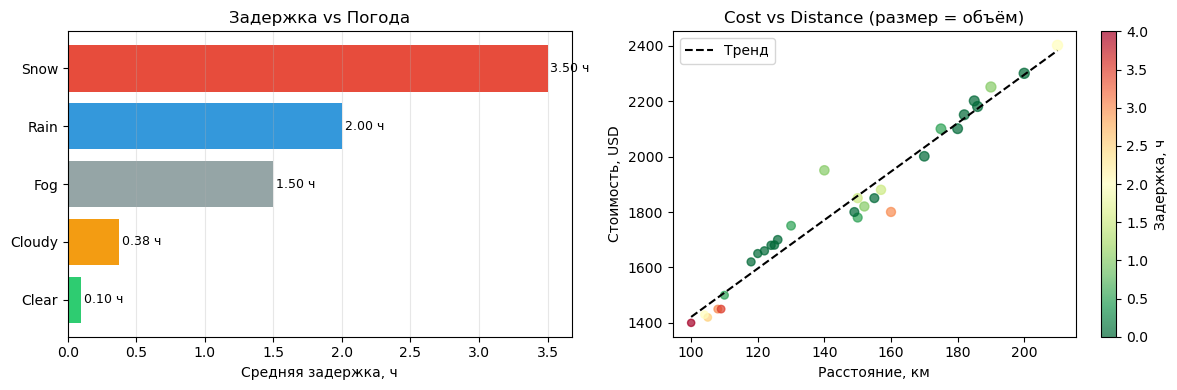

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar: средняя задержка по погоде
colors = {'Clear': '#2ecc71', 'Cloudy': '#f39c12', 'Rain': '#3498db',
          'Fog': '#95a5a6', 'Snow': '#e74c3c'}
ws = weather_stats.sort_values('avg_delay', ascending=True)
bar_colors = [colors.get(w, '#bdc3c7') for w in ws['weather_conditions']]
bars = axes[0].barh(ws['weather_conditions'], ws['avg_delay'], color=bar_colors)
for bar, v in zip(bars, ws['avg_delay']):
    axes[0].text(v + 0.02, bar.get_y() + bar.get_height()/2,
                 f'{v:.2f} ч', va='center', fontsize=9)
axes[0].set_xlabel('Средняя задержка, ч')
axes[0].set_title('Задержка vs Погода')
axes[0].grid(axis='x', alpha=0.3)

# Scatter: стоимость vs расстояние
scatter = axes[1].scatter(
    df['distance_km'], df['cost_usd'],
    c=df['delay_hours'], cmap='RdYlGn_r',
    s=df['volume_ton'] * 1.5, alpha=0.7
)
plt.colorbar(scatter, ax=axes[1], label='Задержка, ч')

# Линия тренда
z = np.polyfit(df['distance_km'], df['cost_usd'], 1)
p = np.poly1d(z)
x_line = np.linspace(df['distance_km'].min(), df['distance_km'].max(), 50)
axes[1].plot(x_line, p(x_line), 'k--', lw=1.5, label='Тренд')
axes[1].set_xlabel('Расстояние, км')
axes[1].set_ylabel('Стоимость, USD')
axes[1].set_title('Cost vs Distance (размер = объём)')
axes[1].legend()

plt.tight_layout()
plt.savefig('chart_10_delay_weather.png', dpi=150)
plt.show()

### 5.2 KPI по водителям

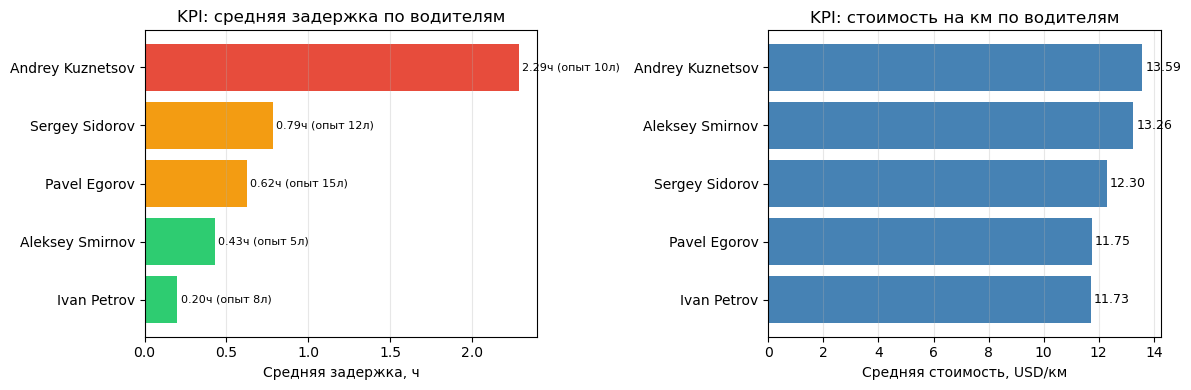

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

dk = driver_kpi.sort_values('avg_delay')

# Задержки
bar_c = ['#e74c3c' if v > 1.5 else '#f39c12' if v > 0.5 else '#2ecc71'
         for v in dk['avg_delay']]
axes[0].barh(dk['driver_name'], dk['avg_delay'], color=bar_c)
axes[0].set_xlabel('Средняя задержка, ч')
axes[0].set_title('KPI: средняя задержка по водителям')
for i, (v, exp) in enumerate(zip(dk['avg_delay'], dk['experience_years'])):
    axes[0].text(v + 0.02, i, f'{v:.2f}ч (опыт {exp}л)', va='center', fontsize=8)
axes[0].grid(axis='x', alpha=0.3)

# Cost/km
dk2 = driver_kpi.sort_values('avg_cost_km')
axes[1].barh(dk2['driver_name'], dk2['avg_cost_km'], color='steelblue')
axes[1].set_xlabel('Средняя стоимость, USD/км')
axes[1].set_title('KPI: стоимость на км по водителям')
for i, v in enumerate(dk2['avg_cost_km']):
    axes[1].text(v + 0.1, i, f'{v:.2f}', va='center', fontsize=9)
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('chart_11_driver_kpi.png', dpi=150)
plt.show()

## 6. Оптимизация маршрутов — ML-модель факторов задержки

              precision    recall  f1-score   support

     Вовремя       0.80      0.80      0.80         5
    Задержка       0.75      0.75      0.75         4

    accuracy                           0.78         9
   macro avg       0.78      0.78      0.78         9
weighted avg       0.78      0.78      0.78         9



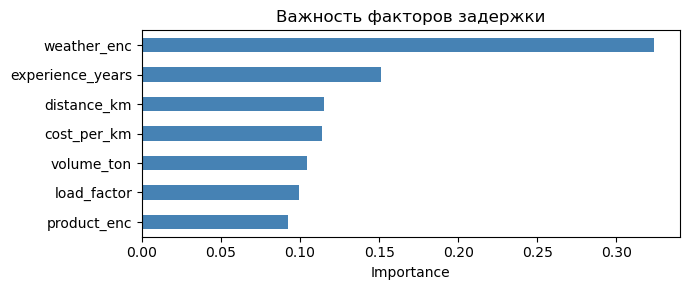

In [8]:
le_weather = LabelEncoder()
le_product = LabelEncoder()

df_ml = df.copy()
df_ml['weather_enc'] = le_weather.fit_transform(df_ml['weather_conditions'])
df_ml['product_enc'] = le_product.fit_transform(df_ml['product_type'])

FEAT = ['distance_km', 'volume_ton', 'weather_enc', 'product_enc',
        'experience_years', 'cost_per_km', 'load_factor']

df_ml = df_ml.dropna(subset=FEAT + ['is_delayed'])
X = df_ml[FEAT].values
y = df_ml['is_delayed'].values

if len(np.unique(y)) > 1 and y.sum() >= 3:
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.3, random_state=42)
    clf = RandomForestClassifier(n_estimators=100, class_weight='balanced',
                                  random_state=42, max_depth=4)
    clf.fit(X_tr, y_tr)
    y_pred = clf.predict(X_te)
    print(classification_report(y_te, y_pred, target_names=['Вовремя', 'Задержка']))

    importances = pd.Series(clf.feature_importances_, index=FEAT).sort_values(ascending=True)
    fig, ax = plt.subplots(figsize=(7, 3))
    importances.plot(kind='barh', ax=ax, color='steelblue')
    ax.set_title('Важность факторов задержки')
    ax.set_xlabel('Importance')
    plt.tight_layout()
    plt.savefig('chart_12_delay_factors.png', dpi=150)
    plt.show()
else:
    print('Недостаточно данных для обучения классификатора — оба класса присутствуют')

## 7. Сводная таблица маршрутов (оптимизация)

In [9]:
route_stats = df.groupby(['source', 'destination']).agg(
    trips        = ('delivery_id',  'count'),
    avg_delay    = ('delay_hours',  'mean'),
    avg_cost_km  = ('cost_per_km',  'mean'),
    distance     = ('distance_km',  'first'),
    bad_weather_pct = ('weather_conditions', lambda x: (x.isin(['Rain','Snow','Fog'])).mean() * 100)
).reset_index()

route_stats['efficiency_score'] = (
    (1 / (route_stats['avg_delay'] + 0.1)) *
    (1 / route_stats['avg_cost_km'])
).round(4)

route_stats_sorted = route_stats.sort_values('efficiency_score', ascending=False)
print('Рейтинг маршрутов по эффективности (топ-10):')
display(route_stats_sorted.head(10)[['source', 'destination', 'distance',
                                      'avg_delay', 'avg_cost_km', 'efficiency_score']])

Рейтинг маршрутов по эффективности (топ-10):


,source,destination,distance,avg_delay,avg_cost_km,efficiency_score
8,Base-Khanty,Station-27,200.0,0.0,11.50,0.8696
0,Base-Khanty,Station-01,180.0,0.0,11.67,0.8569
6,Base-Khanty,Station-19,186.0,0.0,11.72,0.8532
3,Base-Khanty,Station-09,170.0,0.0,11.77,0.8496
5,Base-Khanty,Station-15,182.0,0.0,11.82,0.8460
2,Base-Khanty,Station-06,185.0,0.0,11.90,0.8403
18,Base-Tomsk,Station-12,155.0,0.0,11.94,0.8375
21,Base-Tomsk,Station-24,149.0,0.0,12.08,0.8278
25,Base-Tyumen,Station-13,125.0,0.0,13.45,0.7435
28,Base-Tyumen,Station-25,126.0,0.0,13.49,0.7413


## 8. Итоги

In [10]:
print('=' * 55)
print('ИТОГИ — Логистика и поставки')
print('=' * 55)
print(f'Всего поставок:            {len(df)}')
print(f'Задержанных:               {df["is_delayed"].sum()} ({df["is_delayed"].mean()*100:.0f}%)')
print(f'Средняя задержка:          {df["delay_hours"].mean():.2f} ч')
print(f'Средняя стоимость/км:      {df["cost_per_km"].mean():.2f} USD/км')
print()

worst_weather = weather_stats.iloc[0]
print(f'Наихудшая погода для доставки: {worst_weather["weather_conditions"]} '
      f'(средняя задержка {worst_weather["avg_delay"]:.2f} ч)')

best_driver  = driver_kpi.iloc[0]
worst_driver = driver_kpi.iloc[-1]
print(f'Лучший водитель:  {best_driver["driver_name"]} (задержка {best_driver["avg_delay"]:.2f} ч)')
print(f'Худший водитель:  {worst_driver["driver_name"]} (задержка {worst_driver["avg_delay"]:.2f} ч)')
print()
print('Рекомендации:')
print('  1. Избегать рейсов в снег и туман — задержки максимальны')
print('  2. Приоритет опытным водителям на сложных маршрутах')
print('  3. Оптимальная загрузка ТС: 80-90% от грузоподъёмности')

ИТОГИ — Логистика и поставки
Всего поставок:            30
Задержанных:               16 (53%)
Средняя задержка:          0.93 ч
Средняя стоимость/км:      12.66 USD/км

Наихудшая погода для доставки: Snow (средняя задержка 3.50 ч)
Лучший водитель:  Ivan Petrov (задержка 0.20 ч)
Худший водитель:  Andrey Kuznetsov (задержка 2.29 ч)

Рекомендации:
  1. Избегать рейсов в снег и туман — задержки максимальны
  2. Приоритет опытным водителям на сложных маршрутах
  3. Оптимальная загрузка ТС: 80-90% от грузоподъёмности
